# Lesson 22 activity: unsupervised learning

## Notebook setup

### Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Dataset

In [3]:
df = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0


### Inspect before deciding

Check shape, dtypes, and null counts so the handling strategy is
driven by what's actually in the data rather than assumption.

## Task 1: prepare data for clustering

Prepare the housing dataset for k-means clustering by completing the following steps:

- Check for and handle any missing values in the dataset
- Standardize the features using `StandardScaler` to ensure all variables are on the same scale

In [4]:
print(f'Shape: {df.shape}')
print()
print('Nulls per column:')
print(df.isna().sum())
print()
print('Dtypes:')
print(df.dtypes)
print()
df.describe().T

Shape: (20640, 9)

Nulls per column:
longitude             244
latitude              209
housing_median_age    239
total_rooms           208
total_bedrooms        412
population            219
households            215
median_income         232
median_house_value    229
dtype: int64

Dtypes:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
dtype: object



,count,mean,std,min,25%,50%,75%,max
longitude,20396.0,-119.570279,2.003367,-124.3500,-121.800000,-118.4900,-118.0100,-114.3100
latitude,20431.0,35.631341,2.135438,32.5400,33.930000,34.2600,37.7100,41.9500
housing_median_age,20401.0,28.648890,12.584136,1.0000,18.000000,29.0000,37.0000,52.0000
total_rooms,20432.0,2634.495497,2180.616605,2.0000,1446.000000,2125.0000,3144.0000,39320.0000
total_bedrooms,20228.0,537.853767,420.712338,1.0000,296.000000,435.0000,647.0000,6445.0000
population,20421.0,1425.274864,1131.530160,3.0000,787.000000,1166.0000,1725.0000,35682.0000
households,20425.0,499.527736,382.984732,1.0000,279.000000,409.0000,604.0000,6082.0000
median_income,20408.0,3.870348,1.897645,0.4999,2.564225,3.5355,4.7423,15.0001
median_house_value,20411.0,206943.557396,115441.603232,14999.0000,119600.000000,179800.0000,265000.0000,500001.0000


### Task 1: prepare data for clustering

Nulls are present in all nine columns (roughly 210-245 each, with
`total_bedrooms` higher at 412), so handling cannot target a single
column. Because the nulls are scattered rather than concentrated,
listwise deletion removes substantially more rows than the largest
single-column count suggests.

All columns are numeric, so no encoding is required. The feature
ranges differ by orders of magnitude (`total_rooms` reaches 39,320
while `median_income` tops out at 15), so standardization is required
before any distance-based clustering.

In [7]:
from sklearn.preprocessing import StandardScaler

rows_with_nulls = df.isna().any(axis=1).sum()
print(f'Rows with at least one null: {rows_with_nulls} '
      f'({rows_with_nulls / len(df):.1%})')

df_clean = df.dropna().reset_index(drop=True)
print(f'Rows before: {len(df)}  after: {len(df_clean)}')

feature_cols = df_clean.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[feature_cols])

print(f'Scaled shape: {X_scaled.shape}')
print(f'Mean ~0: {X_scaled.mean():.2e}   Std ~1: {X_scaled.std():.3f}')

Rows with at least one null: 2183 (10.6%)
Rows before: 20640  after: 18457
Scaled shape: (18457, 9)
Mean ~0: 4.28e-16   Std ~1: 1.000


## Task 2: cluster data with k-means

Apply k-means clustering to the prepared data:

- Use the elbow method to determine the optimal number of clusters (k)
  - Test k values from 2 to 10
  - Plot the within-cluster sum of squares (inertia) for each k value
  - Choose an appropriate k value based on the elbow in the plot
- Fit a `KMeans` model with the chosen k value using `random_state=315`
- Add the cluster labels as a new column to the original dataframe
- Create a visualization to show the distribution of data points across clusters

**Hints:**
- The `inertia_` attribute of a fitted KMeans model gives you the within-cluster sum of squares
- A simple loop can help you test multiple k values and store their inertia values
- Use `sklearn.manifold.TSNE` to collapse the features into two dimensions for plotting

### Selecting k

Inertia is plotted alongside silhouette score across k = 2 to 10.
Inertia decreases monotonically with k, so the elbow is a judgment
about diminishing returns rather than a minimum. Silhouette provides
an independent check with a true maximum, which matters here because
real data rarely produces the sharp corner that synthetic examples do.

Silhouette is computed on a 5,000-row sample. The metric is O(n^2) in
the number of points, so a full pass over 18,457 rows costs roughly
eight seconds per k value with no meaningful gain in precision.

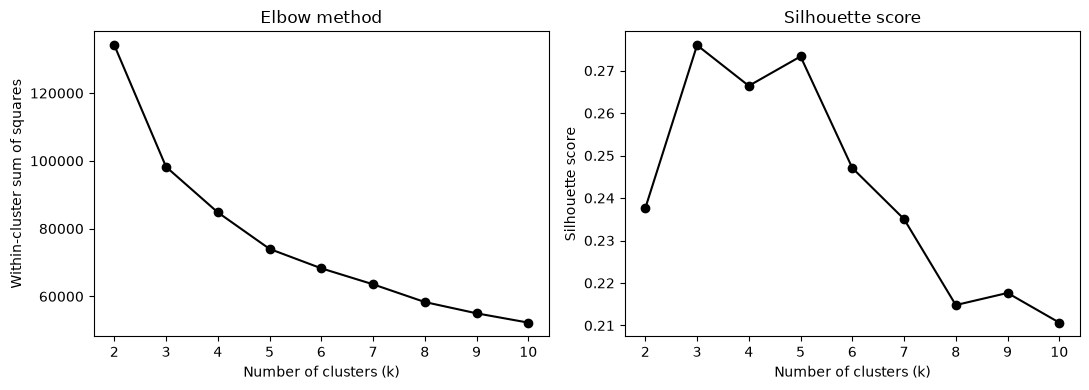

k= 2  inertia=    134136  silhouette=0.2376
k= 3  inertia=     98228  silhouette=0.2760
k= 4  inertia=     84791  silhouette=0.2664
k= 5  inertia=     74010  silhouette=0.2733
k= 6  inertia=     68280  silhouette=0.2471
k= 7  inertia=     63563  silhouette=0.2350
k= 8  inertia=     58329  silhouette=0.2148
k= 9  inertia=     55002  silhouette=0.2177
k=10  inertia=     52252  silhouette=0.2107


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=315)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(
        silhouette_score(X_scaled, labels, sample_size=5000, random_state=315)
    )

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

axs[0].plot(k_range, inertias, marker='o', color='black')
axs[0].set_title('Elbow method')
axs[0].set_xlabel('Number of clusters (k)')
axs[0].set_ylabel('Within-cluster sum of squares')
axs[0].set_xticks(k_range)

axs[1].plot(k_range, silhouettes, marker='o', color='black')
axs[1].set_title('Silhouette score')
axs[1].set_xlabel('Number of clusters (k)')
axs[1].set_ylabel('Silhouette score')
axs[1].set_xticks(k_range)

plt.tight_layout()
plt.show()

for k, inertia, sil in zip(k_range, inertias, silhouettes):
    print(f'k={k:2d}  inertia={inertia:10.0f}  silhouette={sil:.4f}')

### Fitting the final model

Both criteria select k = 3. Inertia falls by 35,908 between k = 2 and
k = 3, roughly three times the 13,437 drop that follows, placing the
elbow at 3. Silhouette peaks independently at the same value (0.2760).
The k = 5 silhouette of 0.2733 sits within sampling noise of the
maximum and is treated as tied rather than as a competing optimum.

The absolute silhouette is low. A score near 0.28 indicates
substantial overlap between clusters, which is expected for real
nine-dimensional data and stands in contrast to the 0.55 typical of
low-dimensional synthetic examples. The segmentation is usable but
the boundaries are not sharp.

Labels are attached to `df_clean`, whose index was reset after null
removal so that row order matches `X_scaled` exactly.

In [9]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=315)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

print(f'Nulls in cluster column: {df_clean["cluster"].isna().sum()}')
print()
print('Cluster sizes:')
print(df_clean['cluster'].value_counts().sort_index())
print()
print('Cluster profiles (feature means):')
df_clean.groupby('cluster')[feature_cols].mean().T.round(2)

Nulls in cluster column: 0

Cluster sizes:
cluster
0    7364
1    9599
2    1494
Name: count, dtype: int64

Cluster profiles (feature means):


cluster,0,1,2
longitude,-121.68,-118.00,-119.21
latitude,37.93,33.91,35.29
housing_median_age,29.69,29.73,16.63
total_rooms,2190.94,2166.11,7893.53
total_bedrooms,436.97,454.16,1578.47
population,1109.67,1269.05,4006.55
households,405.53,425.71,1441.48
median_income,3.74,3.91,4.25
median_house_value,193025.27,214538.47,223193.89


### Visualizing cluster distribution

t-SNE collapses the nine scaled features to two dimensions for
plotting only. The clustering itself was performed in the full feature
space; t-SNE is applied afterward purely to make the result visible.
A 5,000-row sample is used because t-SNE scales poorly with sample
count and the full 18,457 rows add cost without adding clarity.

**Cluster interpretation**

- **Cluster 0 (7,364 districts)** and **Cluster 1 (9,599 districts)**
  are separated almost entirely by geography. Their non-spatial
  features are nearly identical: median age 29.69 vs 29.73, total
  rooms 2,191 vs 2,166, households 406 vs 426, median income 3.74 vs
  3.91. Longitude and latitude place cluster 0 in northern California
  and cluster 1 in the south.
- **Cluster 2 (1,494 districts)** is distinguished by scale rather
  than location. Total rooms, bedrooms, population and households are
  each roughly 3.5 times the other clusters, and median age is 16.6
  against 29.7. These are large, recently built, high-population
  districts. Its intermediate coordinates are an artifact of averaging
  across both regions, not a distinct geographic center.

`median_house_value` contributed little to the segmentation, spanning
only 193k to 223k across clusters while `total_rooms` spans a factor
of 3.6. The structure KMeans found is driven by location and district
size, not by property value.

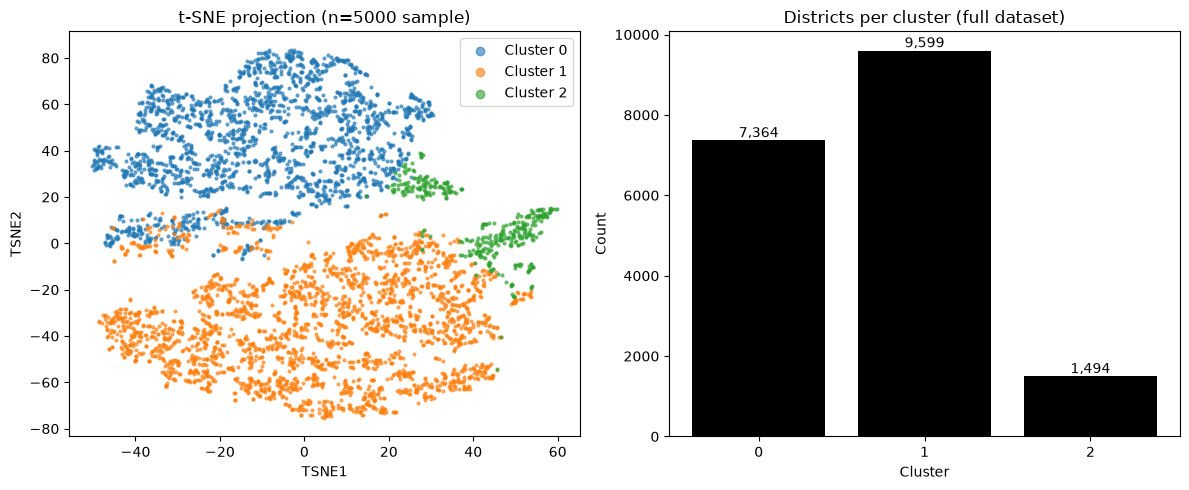

In [10]:
from sklearn.manifold import TSNE

sample_size = 5000
rng = np.random.default_rng(315)
idx = rng.choice(len(df_clean), size=sample_size, replace=False)

X_sample = X_scaled[idx]
labels_sample = df_clean['cluster'].values[idx]

tsne = TSNE(n_components=2, random_state=315)
X_tsne = tsne.fit_transform(X_sample)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for c in sorted(df_clean['cluster'].unique()):
    mask = labels_sample == c
    axs[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   s=4, alpha=0.6, label=f'Cluster {c}')

axs[0].set_title(f't-SNE projection (n={sample_size} sample)')
axs[0].set_xlabel('TSNE1')
axs[0].set_ylabel('TSNE2')
axs[0].legend(markerscale=3)

sizes = df_clean['cluster'].value_counts().sort_index()
axs[1].bar(sizes.index.astype(str), sizes.values, color='black')
axs[1].set_title('Districts per cluster (full dataset)')
axs[1].set_xlabel('Cluster')
axs[1].set_ylabel('Count')

for i, v in enumerate(sizes.values):
    axs[1].text(i, v, f'{v:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

The projection separates clusters 0 and 1 into clean upper and lower
regions with a narrow band of mixing between them, consistent with a
primarily geographic split. Cluster 2 appears as a narrow arc along
the right edge touching both, rather than as an isolated group. This
supports reading its intermediate coordinates as an averaging artifact:
its members are dispersed across both regions and are separated from
the others by scale rather than location.

Note that t-SNE exaggerates local separation by construction. The
visual distinction between clusters 0 and 1 appears sharper here than
the silhouette score of 0.276 indicates, because that score is
computed in the full nine-dimensional space where the boundary is soft.

## Task 3: train a supervised model to assign cluster membership

Build a supervised learning model that can predict cluster assignments for new data:

- Split the data into training and testing sets`
- Use the scaled features from task 1 as the input and the cluster labels from task 2 as the label
- Train a classification model (such as `RandomForestClassifier` or `LogisticRegression`) to predict cluster membership
- Evaluate the model's performance on the test set using appropriate metrics (F1 score, precision, recall, confusion matrix)

## Task 3 approach

The target for this classifier is the cluster label produced by KMeans,
not an externally observed outcome. A high score therefore does not
validate the clustering; it indicates that the classifier successfully
reproduced the geometric decision boundaries KMeans drew. Two things
make that worth doing: the fitted model can assign new districts to a
segment without refitting KMeans over the full dataset, and the feature
importances identify which variables actually drive the segmentation.

Scores should be expected to run high, since both the features and the
labels derive from the same nine columns. A weak result would indicate
a pipeline fault rather than a genuine limit on predictability.

The clusters are unbalanced (7,364 / 9,599 / 1,494), so F1 is reported
under both macro and weighted averaging. Macro treats each cluster
equally and is the more demanding number given the small third cluster;
weighted reflects overall accuracy across districts.

F1 (macro):    0.9852
F1 (weighted): 0.9924

              precision    recall  f1-score   support

           0     0.9906    0.9966    0.9936      1473
           1     0.9969    0.9943    0.9956      1920
           2     0.9729    0.9599    0.9663       299

    accuracy                         0.9924      3692
   macro avg     0.9868    0.9836    0.9852      3692
weighted avg     0.9924    0.9924    0.9924      3692



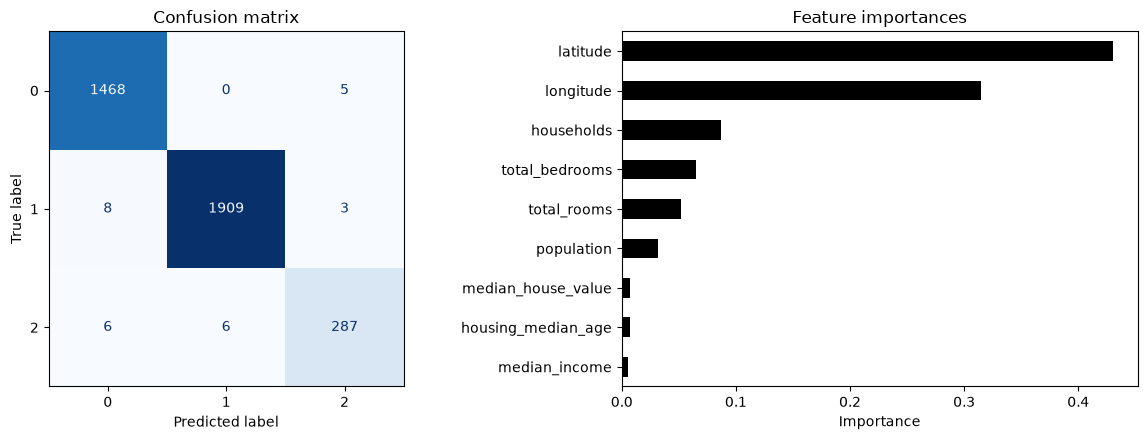

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, ConfusionMatrixDisplay)

y = df_clean['cluster'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=315, stratify=y
)

clf = RandomForestClassifier(random_state=315)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f'F1 (macro):    {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'F1 (weighted): {f1_score(y_test, y_pred, average="weighted"):.4f}')
print()
print(classification_report(y_test, y_pred, digits=4))

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=sorted(set(y))
).plot(ax=axs[0], colorbar=False, cmap='Blues')
axs[0].set_title('Confusion matrix')

importances = pd.Series(clf.feature_importances_, index=feature_cols)
importances.sort_values().plot.barh(ax=axs[1], color='black')
axs[1].set_title('Feature importances')
axs[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

### Results

The classifier reproduces the cluster assignments with macro F1 of
0.9852 and weighted F1 of 0.9924. As anticipated, this reflects
learnability of the KMeans decision boundary rather than validation of
the segmentation itself.

Latitude (0.43) and longitude (0.31) account for roughly 74 percent of
total feature importance. The scale features contribute the next
tranche (households 0.087, total bedrooms 0.065, total rooms 0.052,
population 0.032), while median house value, housing median age and
median income each fall below 0.01. The segmentation is therefore a
geographic partition with a size-based carve-out, and is largely
independent of economic variables. This is consistent with the cluster
profiles, in which median house value spanned only 193k to 223k across
all three groups.

Per-cluster performance is uneven in an informative way. Clusters 0 and
1 are almost never confused with one another (8 errors across roughly
3,400 test districts) despite being geographically adjacent. Cluster 2
carries the highest error rate, with recall of 0.9599 and 12 of 299
districts misassigned. This matches the t-SNE projection, in which
cluster 2 formed an arc bordering both other clusters rather than an
isolated group, and reflects that its members are dispersed across both
regions.

The apparent tension between a low silhouette score (0.276) and near
perfect classification is not a contradiction. Silhouette measures
whether the clusters are well separated in feature space, which they
are not. The classifier only needs to reproduce the boundary KMeans
drew, and that boundary is a deterministic function of the same
features supplied as input. A decision surface can be highly learnable
even when the regions it divides overlap substantially.

### Limitation

Because latitude and longitude dominate the segmentation, the result is
close to a partition of the state map. A segmentation intended to
capture socioeconomic rather than spatial structure would exclude the
coordinate columns and recluster, which would likely surface groups
driven by income, age and property value instead.